# HOMEWORK 13

In this homework you are going to inspect the GTSDB (German Traffic Sign Detection Benchmark) dataset. The dataset contains images of various classes of traffic signs used in Germany (and the whole EU). The objective of this homework is to go through the steps described below and to implement the necessary code.

At the end, as usual, there will be a couple of questions for you to answer. In addition, the last section of this homework is optional and, if you chose to do it, you'll earn extra point :-)

In [1]:
import os
import cv2
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

### Step 0

Go to the GTSRB dataset official site ([link](https://benchmark.ini.rub.de/gtsrb_dataset.html)) to learn more about the dataset.

### Step 1

Download the dataset ([link](https://www.kaggle.com/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign)) and unzip it.

In [7]:
# Train
!wget https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Training_Images.zip

# Test images
!wget https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_Images.zip

# Test labels
!wget https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_GT.zip

--2026-03-24 18:20:49--  https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Training_Images.zip
Resolving sid.erda.dk (sid.erda.dk)... 130.225.104.13
Connecting to sid.erda.dk (sid.erda.dk)|130.225.104.13|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 276294756 (263M) [application/zip]
Saving to: ‘GTSRB_Final_Training_Images.zip’

GTSRB_Final_Trainin 100%[===================>] 263.50M  13.8MB/s    in 18s     

2026-03-24 18:21:08 (14.6 MB/s) - ‘GTSRB_Final_Training_Images.zip’ saved [276294756/276294756]

--2026-03-24 18:21:08--  https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_Images.zip
Resolving sid.erda.dk (sid.erda.dk)... 130.225.104.13
Connecting to sid.erda.dk (sid.erda.dk)|130.225.104.13|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 88978620 (85M) [application/zip]
Saving to: ‘GTSRB_Final_Test_Images.zip’

GTSRB_Final_Test_Im 100%[===================>]  84.8

In [10]:
!unzip -q GTSRB_Final_Training_Images.zip
!unzip -q GTSRB_Final_Test_Images.zip
!unzip -q GTSRB_Final_Test_GT.zip

In [12]:
print(os.listdir())

['.config', 'GTSRB_Final_Test_GT.zip', 'GTSRB.zip', 'GTSRB_Final_Training_Images.zip', 'GTSRB_Final_Test_Images.zip', 'GTSRB', 'GT-final_test.csv', 'sample_data']


In [13]:
!ls GTSRB

Final_Test  Final_Training  Readme-Images-Final-test.txt  Readme-Images.txt


In [14]:
!ls GTSRB/Final_Training

Images


In [15]:
!ls GTSRB/Final_Test

Images


In [16]:
train_path = "GTSRB/Final_Training/Images"
print("Classes:", len(os.listdir(train_path)))

Classes: 43


In [17]:
df = pd.read_csv("GT-final_test.csv")
print(df.head())

  Filename;Width;Height;Roi.X1;Roi.Y1;Roi.X2;Roi.Y2;ClassId
0                       00000.ppm;53;54;6;5;48;49;16       
1                        00001.ppm;42;45;5;5;36;40;1       
2                       00002.ppm;48;52;6;6;43;47;38       
3                       00003.ppm;27;29;5;5;22;24;33       
4                       00004.ppm;60;57;5;5;55;52;11       


In [20]:
root = "GTSRB/Final_Training/Images"

all_data = []

# проходимо по всіх класах
for class_id in os.listdir(root):
    class_path = os.path.join(root, class_id)

    if not os.path.isdir(class_path):
        continue

    # знаходимо CSV
    csv_file = os.path.join(class_path, f"GT-{class_id}.csv")

    df = pd.read_csv(csv_file, sep=';')

    # додаємо шлях і клас
    for _, row in df.iterrows():
        all_data.append({
            "Path": f"Final_Training/Images/{class_id}/{row['Filename']}",
            "ClassId": row['ClassId']
        })

# створюємо DataFrame
train_df = pd.DataFrame(all_data)

# зберігаємо як Train.csv
train_df.to_csv("GTSRB/Train.csv", index=False)

print("Train.csv created:", train_df.shape)

Train.csv created: (39209, 2)


In [21]:
data = pd.read_csv("GTSRB/Train.csv")
print(data.head())

                                          Path  ClassId
0  Final_Training/Images/00037/00000_00000.ppm       37
1  Final_Training/Images/00037/00000_00001.ppm       37
2  Final_Training/Images/00037/00000_00002.ppm       37
3  Final_Training/Images/00037/00000_00003.ppm       37
4  Final_Training/Images/00037/00000_00004.ppm       37


### Step 2

For this homework, you will be working with the training set. Check out the `Train.csv`, open it and see what it contains. Load the dataset and plot random samples.

Number of samples: 39209


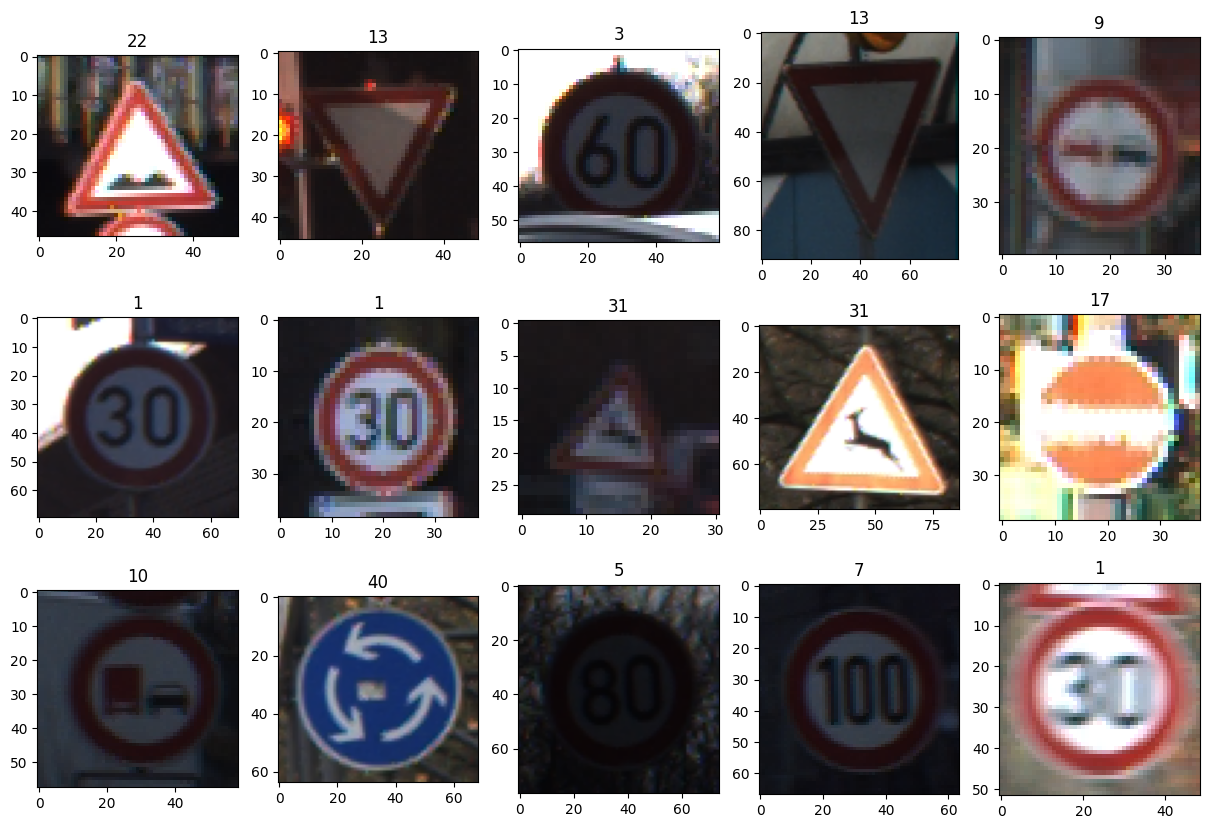

In [22]:
# Load the training labels
root = 'GTSRB' # Path to the dataset location, e.g., '/data/janko/dataset/GTSRB'
data = pd.read_csv(os.path.join(root, 'Train.csv'))

# Number of training samples (amount of samples in data)
num_samples = len(data)
print("Number of samples:", num_samples)


# Show random data samples
for ii in range(15):
    # Get random index
    idx = np.random.randint(0, num_samples)
    # Load image
    img = cv2.imread(os.path.join(root, data.iloc[idx]['Path']))
    # Convert image to RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    # Show image
    plt.subplot(3,5,ii+1), plt.imshow(img), plt.title(data.iloc[idx]['ClassId'])

In [23]:
print(data.columns)
print(len(data))

Index(['Path', 'ClassId'], dtype='object')
39209


Step 3

Inspect the dataset by computing and plotting the per-class histogram.

In [24]:
# Extract class identifiers
# Hint: Check the csv
ids = data['ClassId']

Compute the per class histogram. You can use any approach you want (e.g. `numpy`). It's also worth looking at the `Counter` function from the `collections` module ([link](https://docs.python.org/3/library/collections.html#collections.Counter)) ;-)

(Text(0.5, 0, 'Traffic Sign ID'), Text(0, 0.5, 'Counts'))

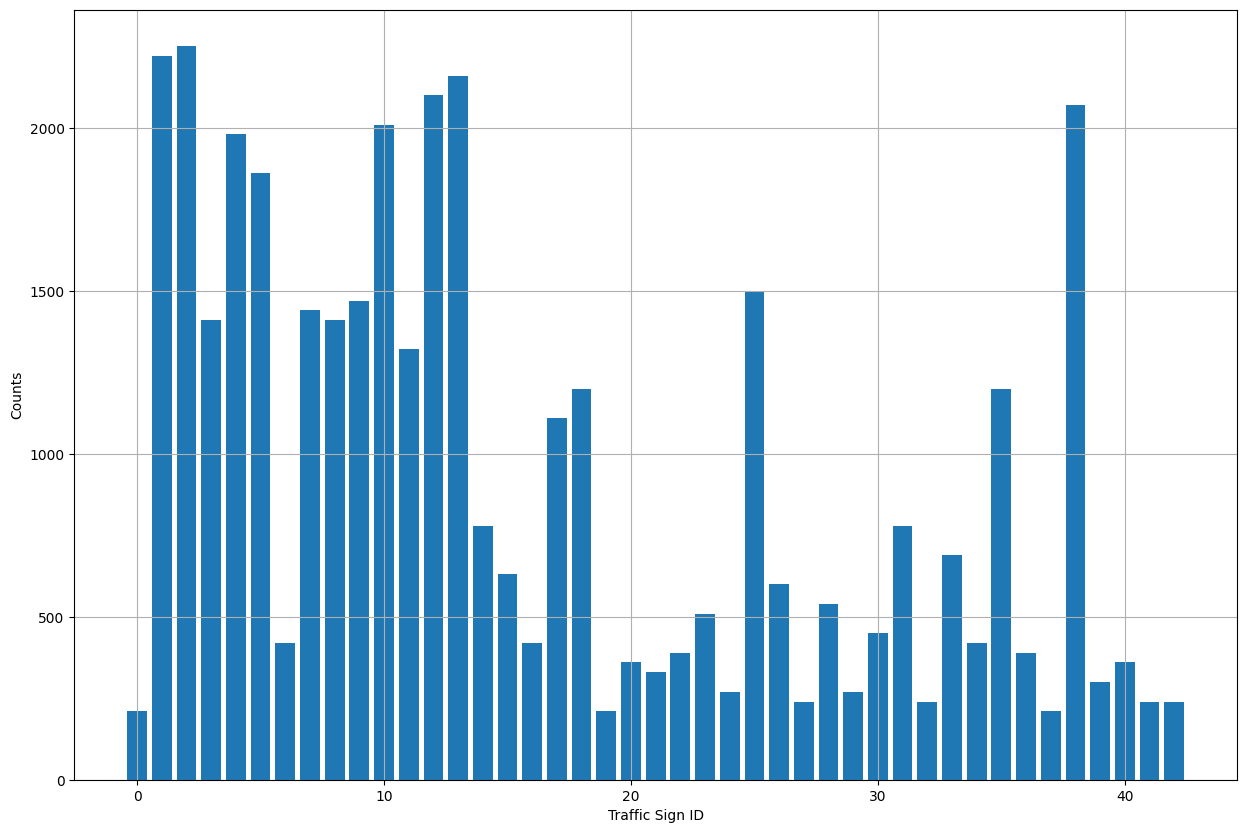

In [25]:
from collections import Counter
hist = Counter(ids)

plt.bar(hist.keys(), hist.values()), plt.grid(True)
plt.xlabel('Traffic Sign ID'), plt.ylabel('Counts')

### Questions

Please answer the following questions:
* Do you consider the dataset to be balanced? If so, why? If not, why?
-Датасет не является сбалансированным. Это хорошо видно по гистограмме, где разные классы имеют существенно разное количество примеров. Некоторые классы содержат значительно больше изображений, чем другие, что указывает на дисбаланс классов.

* Are there any classes that are (significantly) over-represented or under-represeneted?
-Да, в датасете есть как пере-представленные (over-represented), так и недопредставленные (under-represented) классы. Некоторые дорожные знаки имеют большое количество примеров, тогда как другие представлены значительно меньшим числом изображений. Такой дисбаланс может негативно повлиять на качество модели, так как она может быть смещена в сторону более частых классов и хуже распознавать редкие.

### Optional

Perform a further analysis on the dataset and draw some conclusion from it.

Hint 1: Unlike MNIST or CIFAR10, this dataset contains images with various spatial resolutions. Is there anything we can tell about the resolution distribution?
Hint 2: What about the brightness distribution? Are there classes there are significantly more bright than others?